In [1]:
"""
# 01 · Fundamentos de tensores en PyTorch

En este notebook vamos a introducir los conceptos básicos de PyTorch a partir de su objeto central: el "Tensor".

Un tensor puede pensarse como una generalización de escalares, vectores y matrices. En el contexto de imágenes científicas, 
los tensores permiten representar desde una imagen 2D hasta un volumen 3D, un conjunto de imágenes en batch o incluso datos multimodales.

El objetivo de este notebook no es entrenar una red neuronal todavía, sino entender las operaciones fundamentales que después aparecen en 
cualquier modelo de deep learning.

## Objetivos del notebook

Al finalizar este notebook deberíamos poder:

- Crear tensores en PyTorch.
- Entender la diferencia entre "shape", "dtype" y "device".
- Realizar operaciones básicas entre tensores.
- Convertir datos entre NumPy y PyTorch.
- Manipular dimensiones usando "reshape", "view", "flatten", "unsqueeze" y "squeeze".
- Comprender la idea básica de "autograd".
- Verificar si hay una GPU disponible y mover tensores entre CPU y GPU.

## Contexto dentro del portfolio

Este notebook forma parte del módulo de fundamentos de PyTorch del portfolio de Computer Vision aplicado a imágenes científicas.

La idea es construir una base sólida antes de avanzar hacia modelos más complejos, como redes neuronales multicapa, CNNs, modelos de segmentación y, 
más adelante, arquitecturas para datos volumétricos 3D.

"""

'\n# 01 · Fundamentos de tensores en PyTorch\n\nEn este notebook vamos a introducir los conceptos básicos de PyTorch a partir de su objeto central: el "Tensor".\n\nUn tensor puede pensarse como una generalización de escalares, vectores y matrices. En el contexto de imágenes científicas, \nlos tensores permiten representar desde una imagen 2D hasta un volumen 3D, un conjunto de imágenes en batch o incluso datos multimodales.\n\nEl objetivo de este notebook no es entrenar una red neuronal todavía, sino entender las operaciones fundamentales que después aparecen en \ncualquier modelo de deep learning.\n\n## Objetivos del notebook\n\nAl finalizar este notebook deberíamos poder:\n\n- Crear tensores en PyTorch.\n- Entender la diferencia entre "shape", "dtype" y "device".\n- Realizar operaciones básicas entre tensores.\n- Convertir datos entre NumPy y PyTorch.\n- Manipular dimensiones usando "reshape", "view", "flatten", "unsqueeze" y "squeeze".\n- Comprender la idea básica de "autograd".\n- 

In [2]:
# ------------------------------------------------------------
# 01 · Imports and general configuration
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Project paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
DATA_DIR = PROJECT_DIR / "data"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device}")

PyTorch version: 2.10.0+cpu
CUDA available: False
Selected device: cpu


In [3]:
"""
## 1. ¿Qué es un tensor?

Un "Tensor" es la estructura de datos principal en PyTorch. Se puede pensar como una generalización de un número, un vector, 
una matriz o un arreglo multidimensional.

En términos simples:

- Un escalar es un tensor de dimensión 0.
- Un vector es un tensor de dimensión 1.
- Una matriz es un tensor de dimensión 2.
- Una imagen en escala de grises puede representarse como un tensor 2D.
- Una imagen RGB puede representarse como un tensor 3D.
- Un batch de imágenes puede representarse como un tensor 4D.
- Un volumen tomográfico puede representarse como un tensor 3D.

En deep learning, casi todo lo que entra, sale o circula dentro de un modelo está representado como tensores.
"""

'\n## 1. ¿Qué es un tensor?\n\nUn "Tensor" es la estructura de datos principal en PyTorch. Se puede pensar como una generalización de un número, un vector, \nuna matriz o un arreglo multidimensional.\n\nEn términos simples:\n\n- Un escalar es un tensor de dimensión 0.\n- Un vector es un tensor de dimensión 1.\n- Una matriz es un tensor de dimensión 2.\n- Una imagen en escala de grises puede representarse como un tensor 2D.\n- Una imagen RGB puede representarse como un tensor 3D.\n- Un batch de imágenes puede representarse como un tensor 4D.\n- Un volumen tomográfico puede representarse como un tensor 3D.\n\nEn deep learning, casi todo lo que entra, sale o circula dentro de un modelo está representado como tensores.\n'

In [4]:
# ------------------------------------------------------------
# 02 · Creating basic tensors
# ------------------------------------------------------------

# Scalar: tensor with 0 dimensions
scalar = torch.tensor(5)

# Vector: tensor with 1 dimension
vector = torch.tensor([1, 2, 3, 4, 5])

# Matrix: tensor with 2 dimensions
matrix = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

# 3D tensor: useful for representing volumes or multi-channel data
tensor_3d = torch.tensor([
    [[1, 2, 3],
     [4, 5, 6]],

    [[7, 8, 9],
     [10, 11, 12]]
])

print("Scalar:")
print(scalar)
print("Shape:", scalar.shape)
print("Number of dimensions:", scalar.ndim)

print("\nVector:")
print(vector)
print("Shape:", vector.shape)
print("Number of dimensions:", vector.ndim)

print("\nMatrix:")
print(matrix)
print("Shape:", matrix.shape)
print("Number of dimensions:", matrix.ndim)

print("\n3D tensor:")
print(tensor_3d)
print("Shape:", tensor_3d.shape)
print("Number of dimensions:", tensor_3d.ndim)

Scalar:
tensor(5)
Shape: torch.Size([])
Number of dimensions: 0

Vector:
tensor([1, 2, 3, 4, 5])
Shape: torch.Size([5])
Number of dimensions: 1

Matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])
Shape: torch.Size([2, 3])
Number of dimensions: 2

3D tensor:
tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[ 7,  8,  9],
         [10, 11, 12]]])
Shape: torch.Size([2, 2, 3])
Number of dimensions: 3


In [5]:
"""
### Interpretación de las dimensiones

La propiedad "shape" indica el tamaño del tensor en cada dimensión.

Por ejemplo, una matriz con "shape = [2, 3]" tiene 2 filas y 3 columnas.

En imágenes científicas, esta idea es muy importante:

- Una imagen 2D en escala de grises puede tener una forma "(height, width)".
- Una imagen RGB puede tener una forma "(channels, height, width)" o "(height, width, channels)", dependiendo de la librería.
- Un volumen tomográfico puede tener una forma "(depth, height, width)".
- Un conjunto de volúmenes puede tener una forma "(batch, channels, depth, height, width)".

En PyTorch, para imágenes y volúmenes usados en redes neuronales, es común trabajar con la convención donde el canal aparece 
antes de las dimensiones espaciales.
"""

'\n### Interpretación de las dimensiones\n\nLa propiedad "shape" indica el tamaño del tensor en cada dimensión.\n\nPor ejemplo, una matriz con "shape = [2, 3]" tiene 2 filas y 3 columnas.\n\nEn imágenes científicas, esta idea es muy importante:\n\n- Una imagen 2D en escala de grises puede tener una forma "(height, width)".\n- Una imagen RGB puede tener una forma "(channels, height, width)" o "(height, width, channels)", dependiendo de la librería.\n- Un volumen tomográfico puede tener una forma "(depth, height, width)".\n- Un conjunto de volúmenes puede tener una forma "(batch, channels, depth, height, width)".\n\nEn PyTorch, para imágenes y volúmenes usados en redes neuronales, es común trabajar con la convención donde el canal aparece \nantes de las dimensiones espaciales.\n'

In [6]:
# ------------------------------------------------------------
# 03 · Tensors as images and volumes
# ------------------------------------------------------------

# Grayscale image: height x width
grayscale_image = torch.zeros((64, 64))

# RGB image: channels x height x width
rgb_image = torch.zeros((3, 64, 64))

# 3D volume: depth x height x width
volume_3d = torch.zeros((32, 64, 64))

# Batch of grayscale images: batch x channels x height x width
batch_images = torch.zeros((10, 1, 64, 64))

# Batch of 3D volumes: batch x channels x depth x height x width
batch_volumes = torch.zeros((4, 1, 32, 64, 64))

print("Grayscale image shape:", grayscale_image.shape)
print("RGB image shape:", rgb_image.shape)
print("3D volume shape:", volume_3d.shape)
print("Batch of images shape:", batch_images.shape)
print("Batch of volumes shape:", batch_volumes.shape)

Grayscale image shape: torch.Size([64, 64])
RGB image shape: torch.Size([3, 64, 64])
3D volume shape: torch.Size([32, 64, 64])
Batch of images shape: torch.Size([10, 1, 64, 64])
Batch of volumes shape: torch.Size([4, 1, 32, 64, 64])


In [7]:
"""
## 2. Tipo de dato ("dtype") y dispositivo ("device")

Cada tensor tiene asociado:

- Un "tipo de dato" ("dtype"): define cómo se almacenan los números.
- Un "dispositivo" ("device"): indica dónde vive el tensor ("cpu" o "cuda").

Elegir correctamente el tipo de dato impacta en:

- uso de memoria,
- velocidad,
- precisión numérica.

En visión por computadora y deep learning, lo más común es trabajar con "float32".
"""

'\n## 2. Tipo de dato ("dtype") y dispositivo ("device")\n\nCada tensor tiene asociado:\n\n- Un "tipo de dato" ("dtype"): define cómo se almacenan los números.\n- Un "dispositivo" ("device"): indica dónde vive el tensor ("cpu" o "cuda").\n\nElegir correctamente el tipo de dato impacta en:\n\n- uso de memoria,\n- velocidad,\n- precisión numérica.\n\nEn visión por computadora y deep learning, lo más común es trabajar con "float32".\n'

In [8]:
# ------------------------------------------------------------
# 04 · dtype and device
# ------------------------------------------------------------

a = torch.tensor([1, 2, 3])
b = torch.tensor([1.0, 2.0, 3.0])
c = torch.tensor([1, 2, 3], dtype=torch.float32)
d = torch.tensor([1, 2, 3], dtype=torch.int64)

print("Tensor a:", a)
print("dtype:", a.dtype)
print("device:", a.device)

print("\nTensor b:", b)
print("dtype:", b.dtype)
print("device:", b.device)

print("\nTensor c:", c)
print("dtype:", c.dtype)

print("\nTensor d:", d)
print("dtype:", d.dtype)

Tensor a: tensor([1, 2, 3])
dtype: torch.int64
device: cpu

Tensor b: tensor([1., 2., 3.])
dtype: torch.float32
device: cpu

Tensor c: tensor([1., 2., 3.])
dtype: torch.float32

Tensor d: tensor([1, 2, 3])
dtype: torch.int64


In [9]:
# Convert integer tensor to float

x = torch.tensor([10, 20, 30])

x_float = x.float()
x_double = x.double()

print("Original dtype :", x.dtype)
print("Float dtype    :", x_float.dtype)
print("Double dtype   :", x_double.dtype)

Original dtype : torch.int64
Float dtype    : torch.float32
Double dtype   : torch.float64


In [10]:
"""
### Nota práctica

Cuando entrenamos redes neuronales, los datos de entrada suelen convertirse a "float32".

Por ejemplo:

- imágenes originales: "uint8" (0 a 255)
- después de normalizar: "float32"

Las etiquetas de clasificación suelen mantenerse como enteros ("int64") porque muchas funciones de pérdida en PyTorch las esperan así.

## 3. Creación automática de tensores

PyTorch incluye funciones muy útiles para crear tensores sin cargar datos manualmente.

Estas herramientas se usan para:

- inicializar pesos,
- generar datos sintéticos,
- crear máscaras,
- preparar batches vacíos,
- simular ruido,
- construir ejes y coordenadas.
"""

'\n### Nota práctica\n\nCuando entrenamos redes neuronales, los datos de entrada suelen convertirse a "float32".\n\nPor ejemplo:\n\n- imágenes originales: "uint8" (0 a 255)\n- después de normalizar: "float32"\n\nLas etiquetas de clasificación suelen mantenerse como enteros ("int64") porque muchas funciones de pérdida en PyTorch las esperan así.\n\n## 3. Creación automática de tensores\n\nPyTorch incluye funciones muy útiles para crear tensores sin cargar datos manualmente.\n\nEstas herramientas se usan para:\n\n- inicializar pesos,\n- generar datos sintéticos,\n- crear máscaras,\n- preparar batches vacíos,\n- simular ruido,\n- construir ejes y coordenadas.\n'

In [11]:
# ------------------------------------------------------------
# 05 · Automatic tensor creation
# ------------------------------------------------------------

zeros_tensor = torch.zeros((2, 3))
ones_tensor = torch.ones((2, 3))

random_uniform = torch.rand((2, 3))
random_normal = torch.randn((2, 3))

sequence = torch.arange(0, 10, 2)
linear_space = torch.linspace(0, 1, 5)

print("Zeros tensor:\n", zeros_tensor)
print("\nOnes tensor:\n", ones_tensor)

print("\nRandom uniform [0,1):\n", random_uniform)
print("\nRandom normal N(0,1):\n", random_normal)

print("\nArange sequence:\n", sequence)
print("\nLinspace sequence:\n", linear_space)

Zeros tensor:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

Ones tensor:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])

Random uniform [0,1):
 tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])

Random normal N(0,1):
 tensor([[ 1.1561,  0.3965, -2.4661],
        [ 0.3623,  0.3765, -0.1808]])

Arange sequence:
 tensor([0, 2, 4, 6, 8])

Linspace sequence:
 tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


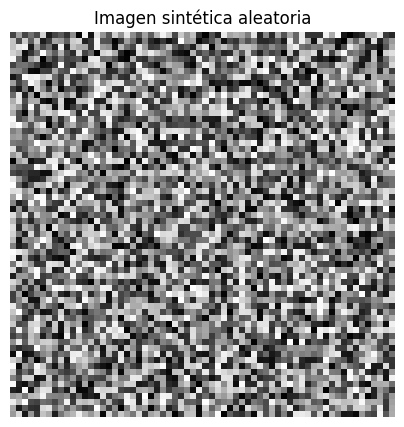

Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\02_pytorch_basics\figures\synthetic_random_image.png


In [12]:
# ------------------------------------------------------------
# 06 · Synthetic image from random values
# ------------------------------------------------------------

synthetic_image = torch.rand((64, 64))

plt.figure(figsize=(5, 5))
plt.imshow(synthetic_image, cmap="gray")
plt.title("Imagen sintética aleatoria")
plt.axis("off")

out = FIGURES_DIR / "synthetic_random_image.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {out}")

In [13]:
"""
### Diferencia entre "rand()" y "randn()"

- "torch.rand()" genera valores uniformes entre 0 y 1.
- "torch.randn()" genera valores con distribución normal estándar (media 0, desvío 1).

En deep learning:

- "rand()" sirve para imágenes sintéticas o máscaras.
- "randn()" se usa mucho en inicialización de pesos y ruido gaussiano.
"""
# ------------------------------------------------------------
# 07 · Coordinate axis example
# ------------------------------------------------------------

x = torch.linspace(-5, 5, 11)
y = x**2

print("x =", x)
print("y = x² =", y)

x = tensor([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.])
y = x² = tensor([25., 16.,  9.,  4.,  1.,  0.,  1.,  4.,  9., 16., 25.])


In [14]:
"""
## 4. Operaciones básicas entre tensores

Los tensores permiten realizar operaciones algebraicas de forma eficiente.

Muchas ecuaciones de machine learning pueden escribirse como operaciones entre matrices y vectores, por lo que dominar esta sección es fundamental.

Vamos a ver:

- suma y resta,
- multiplicación elemento a elemento,
- división,
- potencias,
- producto matricial,
- estadísticas básicas.
"""

'\n## 4. Operaciones básicas entre tensores\n\nLos tensores permiten realizar operaciones algebraicas de forma eficiente.\n\nMuchas ecuaciones de machine learning pueden escribirse como operaciones entre matrices y vectores, por lo que dominar esta sección es fundamental.\n\nVamos a ver:\n\n- suma y resta,\n- multiplicación elemento a elemento,\n- división,\n- potencias,\n- producto matricial,\n- estadísticas básicas.\n'

In [15]:
# ------------------------------------------------------------
# 08 · Basic tensor operations
# ------------------------------------------------------------

a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Tensor a:", a)
print("Tensor b:", b)

print("\nAddition:")
print(a + b)

print("\nSubtraction:")
print(a - b)

print("\nElement-wise multiplication:")
print(a * b)

print("\nDivision:")
print(a / b)

print("\nPower:")
print(a ** 2)

Tensor a: tensor([1., 2., 3.])
Tensor b: tensor([4., 5., 6.])

Addition:
tensor([5., 7., 9.])

Subtraction:
tensor([-3., -3., -3.])

Element-wise multiplication:
tensor([ 4., 10., 18.])

Division:
tensor([0.2500, 0.4000, 0.5000])

Power:
tensor([1., 4., 9.])


In [16]:
# ------------------------------------------------------------
# 09 · Statistics on tensors
# ------------------------------------------------------------

x = torch.tensor([2.0, 4.0, 6.0, 8.0])

print("Tensor:", x)
print("Mean :", x.mean())
print("Sum  :", x.sum())
print("Max  :", x.max())
print("Min  :", x.min())
print("Std  :", x.std())

Tensor: tensor([2., 4., 6., 8.])
Mean : tensor(5.)
Sum  : tensor(20.)
Max  : tensor(8.)
Min  : tensor(2.)
Std  : tensor(2.5820)


In [17]:
"""
### Producto elemento a elemento vs producto matricial

No deben confundirse:

- "a * b" multiplica posición por posición.
- "matmul()" o "@" realiza álgebra matricial real.

Esto último es central en redes neuronales:

\[
y = Wx + b
\]

donde:

- "x" = entrada  
- "W" = pesos  
- "b" = bias
"""

'\n### Producto elemento a elemento vs producto matricial\n\nNo deben confundirse:\n\n- "a * b" multiplica posición por posición.\n- "matmul()" o "@" realiza álgebra matricial real.\n\nEsto último es central en redes neuronales:\n\n\\[\ny = Wx + b\n\\]\n\ndonde:\n\n- "x" = entrada  \n- "W" = pesos  \n- "b" = bias\n'

In [18]:
# ------------------------------------------------------------
# 10 · Matrix multiplication
# ------------------------------------------------------------

A = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]
])

B = torch.tensor([
    [5.0, 6.0],
    [7.0, 8.0]
])

print("Matrix A:\n", A)
print("\nMatrix B:\n", B)

print("\nElement-wise multiplication:")
print(A * B)

print("\nMatrix multiplication (A @ B):")
print(A @ B)

Matrix A:
 tensor([[1., 2.],
        [3., 4.]])

Matrix B:
 tensor([[5., 6.],
        [7., 8.]])

Element-wise multiplication:
tensor([[ 5., 12.],
        [21., 32.]])

Matrix multiplication (A @ B):
tensor([[19., 22.],
        [43., 50.]])


In [19]:
# ------------------------------------------------------------
# 11 · Simple linear model manually
# ------------------------------------------------------------

x = torch.tensor([2.0, 3.0])
W = torch.tensor([
    [1.0, 0.5],
    [0.2, 2.0]
])
b = torch.tensor([0.1, -0.3])

y = W @ x + b

print("Input x:", x)
print("Output y:", y)

Input x: tensor([2., 3.])
Output y: tensor([3.6000, 6.1000])


In [20]:
"""
### Conexión con redes neuronales

Una capa totalmente conectada ("Linear Layer") hace exactamente este tipo de operación:

\[
y = Wx + b
\]

Luego suele aplicarse una función no lineal como:

- ReLU
- Sigmoid
- Tanh

Más adelante veremos cómo PyTorch implementa esto automáticamente con "nn.Linear".
"""

'\n### Conexión con redes neuronales\n\nUna capa totalmente conectada ("Linear Layer") hace exactamente este tipo de operación:\n\n\\[\ny = Wx + b\n\\]\n\nLuego suele aplicarse una función no lineal como:\n\n- ReLU\n- Sigmoid\n- Tanh\n\nMás adelante veremos cómo PyTorch implementa esto automáticamente con "nn.Linear".\n'

In [21]:
# ------------------------------------------------------------
# 12 · Shape inspection
# ------------------------------------------------------------

x = torch.arange(12)

print("Tensor x:")
print(x)

print("\nShape:", x.shape)
print("Dimensions:", x.ndim)
print("Number of elements:", x.numel())

Tensor x:
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

Shape: torch.Size([12])
Dimensions: 1
Number of elements: 12


In [22]:
# ------------------------------------------------------------
# 13 · Reshape
# ------------------------------------------------------------

x_2d = x.reshape(3, 4)

print("Reshaped tensor (3x4):")
print(x_2d)
print("Shape:", x_2d.shape)

Reshaped tensor (3x4):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Shape: torch.Size([3, 4])


In [23]:
# ------------------------------------------------------------
# 14 · Flatten
# ------------------------------------------------------------

flat = x_2d.flatten()

print("Flattened tensor:")
print(flat)
print("Shape:", flat.shape)

Flattened tensor:
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Shape: torch.Size([12])


In [24]:
# ------------------------------------------------------------
# 15 · Unsqueeze and squeeze
# ------------------------------------------------------------

image = torch.rand((64, 64))

print("Original shape:", image.shape)

image_batch = image.unsqueeze(0)
print("After unsqueeze(0):", image_batch.shape)

image_channel = image_batch.unsqueeze(0)
print("After second unsqueeze:", image_channel.shape)

restored = image_channel.squeeze()

print("After squeeze():", restored.shape)

Original shape: torch.Size([64, 64])
After unsqueeze(0): torch.Size([1, 64, 64])
After second unsqueeze: torch.Size([1, 1, 64, 64])
After squeeze(): torch.Size([64, 64])


In [25]:
# ------------------------------------------------------------
# 16 · Transpose
# ------------------------------------------------------------

A = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

print("Original:")
print(A)
print("Shape:", A.shape)

AT = A.T

print("\nTranspose:")
print(AT)
print("Shape:", AT.shape)

Original:
tensor([[1, 2, 3],
        [4, 5, 6]])
Shape: torch.Size([2, 3])

Transpose:
tensor([[1, 4],
        [2, 5],
        [3, 6]])
Shape: torch.Size([3, 2])


In [27]:
"""
### ¿Por qué esto importa en Computer Vision?

Las redes convolucionales suelen esperar tensores con forma:

"text
(batch, channels, height, width)

## 6. Conversión entre NumPy y PyTorch

PyTorch y NumPy trabajan muy bien juntos.

Esto es importante porque muchos flujos científicos usan:

- NumPy para cálculo numérico,
- scikit-image para procesamiento de imágenes,
- matplotlib para visualización,
- PyTorch para deep learning.

Por eso es común mover datos entre ambos ecosistemas.
"""

'\n### ¿Por qué esto importa en Computer Vision?\n\nLas redes convolucionales suelen esperar tensores con forma:\n\n"text\n(batch, channels, height, width)\n\n## 6. Conversión entre NumPy y PyTorch\n\nPyTorch y NumPy trabajan muy bien juntos.\n\nEsto es importante porque muchos flujos científicos usan:\n\n- NumPy para cálculo numérico,\n- scikit-image para procesamiento de imágenes,\n- matplotlib para visualización,\n- PyTorch para deep learning.\n\nPor eso es común mover datos entre ambos ecosistemas.\n'

In [28]:
# ------------------------------------------------------------
# 18 · NumPy to PyTorch
# ------------------------------------------------------------

np_array = np.array([
    [1, 2, 3],
    [4, 5, 6]
], dtype=np.float32)

tensor_from_numpy = torch.from_numpy(np_array)

print("NumPy array:")
print(np_array)
print(type(np_array))

print("\nConverted tensor:")
print(tensor_from_numpy)
print(type(tensor_from_numpy))
print("dtype:", tensor_from_numpy.dtype)

NumPy array:
[[1. 2. 3.]
 [4. 5. 6.]]
<class 'numpy.ndarray'>

Converted tensor:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
<class 'torch.Tensor'>
dtype: torch.float32


In [29]:
# ------------------------------------------------------------
# 19 · PyTorch to NumPy
# ------------------------------------------------------------

tensor_x = torch.tensor([
    [10.0, 20.0],
    [30.0, 40.0]
])

numpy_x = tensor_x.numpy()

print("Tensor:")
print(tensor_x)

print("\nConverted NumPy array:")
print(numpy_x)
print(type(numpy_x))

Tensor:
tensor([[10., 20.],
        [30., 40.]])

Converted NumPy array:
[[10. 20.]
 [30. 40.]]
<class 'numpy.ndarray'>


In [30]:
"""
### Atención: memoria compartida

Cuando usamos:

- "torch.from_numpy()"
- "tensor.numpy()"

muchas veces ambos objetos comparten memoria.

Eso significa que modificar uno puede modificar el otro.
"""

'\n### Atención: memoria compartida\n\nCuando usamos:\n\n- "torch.from_numpy()"\n- "tensor.numpy()"\n\nmuchas veces ambos objetos comparten memoria.\n\nEso significa que modificar uno puede modificar el otro.\n'

In [31]:
# ------------------------------------------------------------
# 20 · Shared memory example
# ------------------------------------------------------------

arr = np.array([1, 2, 3], dtype=np.float32)
t = torch.from_numpy(arr)

print("Original:")
print("NumPy :", arr)
print("Tensor:", t)

arr[0] = 99

print("\nAfter modifying NumPy:")
print("NumPy :", arr)
print("Tensor:", t)

Original:
NumPy : [1. 2. 3.]
Tensor: tensor([1., 2., 3.])

After modifying NumPy:
NumPy : [99.  2.  3.]
Tensor: tensor([99.,  2.,  3.])


In [32]:
# ------------------------------------------------------------
# 21 · Independent copy
# ------------------------------------------------------------

arr2 = np.array([5, 6, 7], dtype=np.float32)

t2 = torch.tensor(arr2)   # creates copy

arr2[0] = 999

print("NumPy :", arr2)
print("Tensor:", t2)

NumPy : [999.   6.   7.]
Tensor: tensor([5., 6., 7.])


In [33]:
"""
### Flujo típico en Computer Vision científico

Muchas veces el pipeline real es:

"text
TIFF / PNG / RAW image
↓
NumPy array
↓
Preprocesamiento con scikit-image / OpenCV
↓
Tensor PyTorch
↓
Modelo de Deep Learning
↓
Resultado a NumPy
↓
Visualización o análisis

## 7. Broadcasting

El broadcasting permite operar tensores de distintas formas ("shape") sin copiar datos manualmente.

PyTorch expande automáticamente dimensiones compatibles para poder realizar la operación.

Esto es muy útil para:

- sumar biases,
- normalizar imágenes,
- escalar canales,
- restar medias,
- operaciones vectorizadas rápidas.
"""

'\n### Flujo típico en Computer Vision científico\n\nMuchas veces el pipeline real es:\n\n"text\nTIFF / PNG / RAW image\n↓\nNumPy array\n↓\nPreprocesamiento con scikit-image / OpenCV\n↓\nTensor PyTorch\n↓\nModelo de Deep Learning\n↓\nResultado a NumPy\n↓\nVisualización o análisis\n\n## 7. Broadcasting\n\nEl broadcasting permite operar tensores de distintas formas ("shape") sin copiar datos manualmente.\n\nPyTorch expande automáticamente dimensiones compatibles para poder realizar la operación.\n\nEsto es muy útil para:\n\n- sumar biases,\n- normalizar imágenes,\n- escalar canales,\n- restar medias,\n- operaciones vectorizadas rápidas.\n'

In [34]:
# ------------------------------------------------------------
# 23 · Basic broadcasting
# ------------------------------------------------------------

A = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])

b = torch.tensor([10.0, 20.0, 30.0])

C = A + b

print("Matrix A:")
print(A)
print("Shape:", A.shape)

print("\nVector b:")
print(b)
print("Shape:", b.shape)

print("\nA + b:")
print(C)
print("Shape:", C.shape)

Matrix A:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape: torch.Size([2, 3])

Vector b:
tensor([10., 20., 30.])
Shape: torch.Size([3])

A + b:
tensor([[11., 22., 33.],
        [14., 25., 36.]])
Shape: torch.Size([2, 3])


In [35]:
# ------------------------------------------------------------
# 24 · Column broadcasting
# ------------------------------------------------------------

col = torch.tensor([[100.0],
                    [200.0]])

result = A + col

print(result)

tensor([[101., 102., 103.],
        [204., 205., 206.]])


In [36]:
# ------------------------------------------------------------
# 25 · Image normalization example
# ------------------------------------------------------------

image = torch.rand((3, 64, 64))   # RGB image

mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
std  = torch.tensor([0.2, 0.2, 0.2]).view(3, 1, 1)

normalized = (image - mean) / std

print("Image shape      :", image.shape)
print("Mean shape       :", mean.shape)
print("Normalized shape :", normalized.shape)

Image shape      : torch.Size([3, 64, 64])
Mean shape       : torch.Size([3, 1, 1])
Normalized shape : torch.Size([3, 64, 64])


In [37]:
"""
### Imagen RGB en PyTorch

Una imagen RGB suele tener forma:

"text
(3, height, width)

### ¿Por qué importa?

Sin broadcasting tendríamos que escribir loops lentos y verbosos.

Con broadcasting:

- el código es más limpio,
- más rápido,
- más matemático,
- más cercano a cómo escribimos ecuaciones.
"""

'\n### Imagen RGB en PyTorch\n\nUna imagen RGB suele tener forma:\n\n"text\n(3, height, width)\n\n### ¿Por qué importa?\n\nSin broadcasting tendríamos que escribir loops lentos y verbosos.\n\nCon broadcasting:\n\n- el código es más limpio,\n- más rápido,\n- más matemático,\n- más cercano a cómo escribimos ecuaciones.\n'

In [38]:
"""
## 8. Gradientes automáticos con "autograd"

Una de las grandes ventajas de PyTorch es que puede calcular derivadas automáticamente.

Esto permite entrenar redes neuronales sin derivar a mano miles o millones de parámetros.

La idea es:

1. Definimos una función.
2. PyTorch registra las operaciones.
3. Calcula el gradiente con "backward()".

En Machine Learning esto se usa para minimizar funciones de pérdida.
"""
# ------------------------------------------------------------
# 27 · Simple derivative
# ------------------------------------------------------------

x = torch.tensor(2.0, requires_grad=True)

y = x**2

print("x =", x)
print("y =", y)

y.backward()

print("dy/dx =", x.grad)

x = tensor(2., requires_grad=True)
y = tensor(4., grad_fn=<PowBackward0>)
dy/dx = tensor(4.)


In [39]:
# ------------------------------------------------------------
# 28 · More complex function
# ------------------------------------------------------------

x = torch.tensor(3.0, requires_grad=True)

f = x**3 + 2*x**2 - x + 1

f.backward()

print("x =", x.item())
print("f(x) =", f.item())
print("df/dx =", x.grad.item())

x = 3.0
f(x) = 43.0
df/dx = 38.0


In [40]:
# ------------------------------------------------------------
# 29 · Gradient in vector expression
# ------------------------------------------------------------

x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

y = (x**2).sum()

y.backward()

print("x =", x)
print("Gradient =", x.grad)

x = tensor([1., 2., 3.], requires_grad=True)
Gradient = tensor([2., 4., 6.])


In [41]:
# ------------------------------------------------------------
# 30 · Tiny loss example
# ------------------------------------------------------------

w = torch.tensor(0.5, requires_grad=True)

x = torch.tensor(2.0)
target = torch.tensor(5.0)

prediction = w * x
loss = (prediction - target)**2

loss.backward()

print("Prediction:", prediction.item())
print("Loss:", loss.item())
print("dLoss/dw:", w.grad.item())

Prediction: 1.0
Loss: 16.0
dLoss/dw: -16.0


In [43]:
"""
### Relación con Física

Esto es equivalente a optimizar una energía potencial o minimizar una función objetivo.

Buscamos parámetros donde la pendiente sea cero:

"text
gradiente = 0

### Idea central

PyTorch combina:

- álgebra de tensores,
- grafo computacional,
- cálculo automático de derivadas.

Eso hace posible entrenar modelos complejos con pocas líneas de código.

## 9. CPU vs GPU

PyTorch permite ejecutar operaciones en distintos dispositivos.

Los más comunes son:

- "cpu": procesador tradicional.
- "cuda": GPU NVIDIA compatible con CUDA.

Las GPUs son especialmente útiles para:

- entrenamiento de redes neuronales,
- batches grandes,
- CNNs,
- modelos 3D,
- millones de operaciones matriciales paralelas.

"""

'\n### Relación con Física\n\nEsto es equivalente a optimizar una energía potencial o minimizar una función objetivo.\n\nBuscamos parámetros donde la pendiente sea cero:\n\n"text\ngradiente = 0\n\n### Idea central\n\nPyTorch combina:\n\n- álgebra de tensores,\n- grafo computacional,\n- cálculo automático de derivadas.\n\nEso hace posible entrenar modelos complejos con pocas líneas de código.\n\n## 9. CPU vs GPU\n\nPyTorch permite ejecutar operaciones en distintos dispositivos.\n\nLos más comunes son:\n\n- "cpu": procesador tradicional.\n- "cuda": GPU NVIDIA compatible con CUDA.\n\nLas GPUs son especialmente útiles para:\n\n- entrenamiento de redes neuronales,\n- batches grandes,\n- CNNs,\n- modelos 3D,\n- millones de operaciones matriciales paralelas.\n\n'

In [44]:
# ------------------------------------------------------------
# 32 · Check available device
# ------------------------------------------------------------

print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Selected device:", device)

CUDA available: False
Selected device: cpu


In [45]:
# ------------------------------------------------------------
# 33 · Move tensor to device
# ------------------------------------------------------------

x = torch.rand((3, 3))

x_device = x.to(device)

print("Original device:", x.device)
print("New device:", x_device.device)

Original device: cpu
New device: cpu


In [ ]:
"